In [12]:
import sys
sys.path.insert(0, '../Results')
sys.path.insert(0, '../../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from python_utils.visualization_utils import create_summary_table, plot_snr_performance

In [13]:
if not os.path.exists("Figures"):
    os.mkdir("Figures")

# 10 by 5 Mixing Results

In [14]:
df_predictiveBSS = pd.read_pickle(r"../Results/predictive_bss_noisy_simplex_10by5_results.pkl")
df_predictiveBSS.tail()

,Model,seed,SINR,SNR,SNRinp,execution_time
355,LDMIBSS,2701,5.537561,"[[6.498622416303337, 5.267888237384602, 6.2225...",5.0,19.766311
356,PredictiveDecorrBSS,2801,7.299377,"[[5.507514649587325, 7.997963168310975, 7.2236...",5.0,16.657963
357,LDMIBSS,2801,6.932082,"[[5.637076009155803, 7.327177094094937, 6.5092...",5.0,19.818813
358,PredictiveDecorrBSS,2901,7.374018,"[[6.226342642530418, 7.796331265411826, 9.6332...",5.0,16.778785
359,LDMIBSS,2901,6.852488,"[[5.726838595855874, 7.052914189867772, 9.1943...",5.0,19.739612


In [15]:
df_upem = pd.read_pickle(r"../Results/upem_noisy_simplex_10by5_results.pkl")
k = len(df_predictiveBSS["Model"].unique())
def interleave(A, B,k):
    nA, nB = len(A), len(B)

    # Group index for A (every k rows = one group)
    groups_A = np.arange(nA) // k

    # Position within each group (A rows come first)
    pos_A = np.arange(nA) % k

    # Build DataFrame with ordering keys
    A_ = A.copy()
    A_['_grp'] = groups_A
    A_['_pos'] = pos_A
    A_['_src'] = 0  # A comes before B within group

    # For B: one row per group
    B_ = B.iloc[:groups_A.max() + 1].copy()
    B_['_grp'] = np.arange(len(B_))
    B_['_pos'] = k   # comes after the 5 A rows
    B_['_src'] = 1

    # Combine and sort once
    out = pd.concat([A_, B_], ignore_index=True)
    out = out.sort_values(['_grp', '_pos', '_src'])

    return out.drop(columns=['_grp', '_pos', '_src']).reset_index(drop=True)
df_combined = interleave(df_predictiveBSS, df_upem,k)

In [16]:
summary_df = create_summary_table(df_combined)
# summary_df

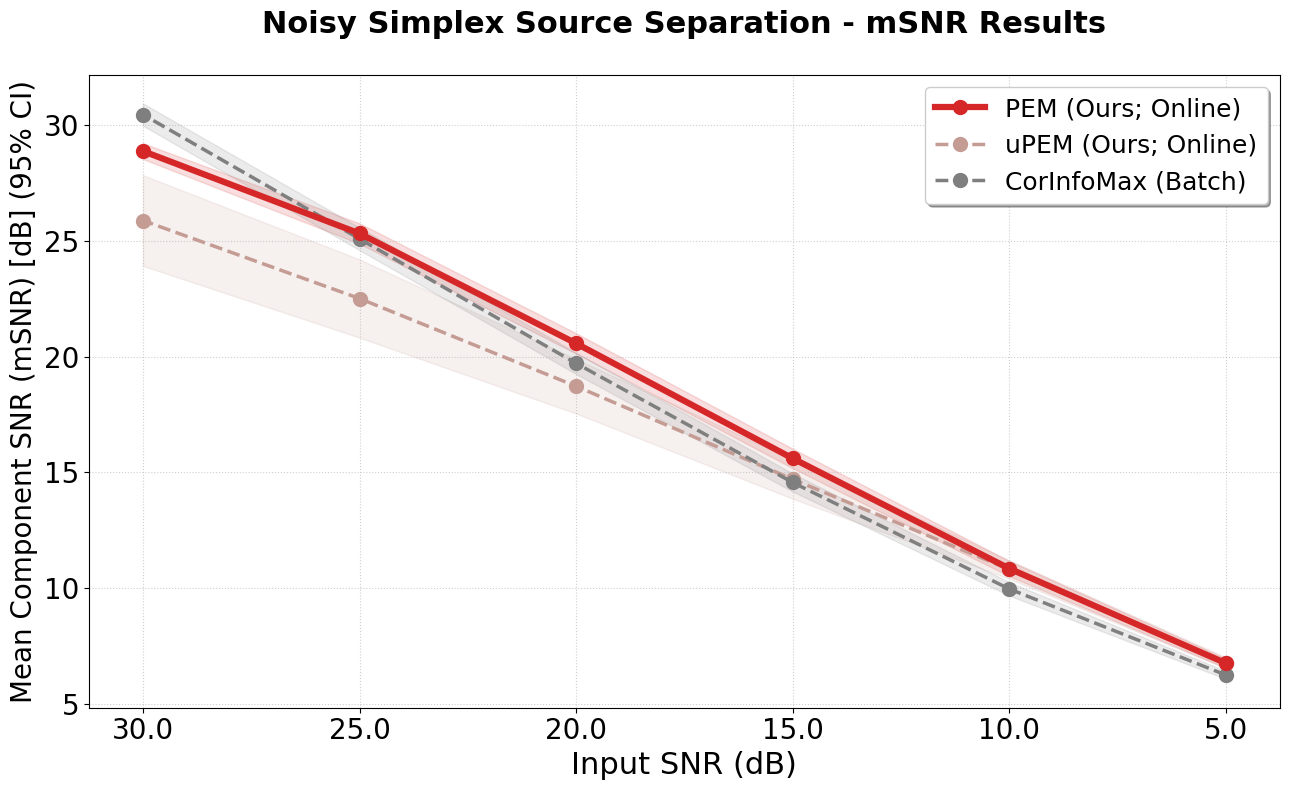

In [17]:
plot_title = "Noisy Simplex Source Separation - mSNR Results"
bss_plot = plot_snr_performance(summary_df, 'SNRinp', title = plot_title)
# plt.savefig('Figures/Simplex_Noisy_Comparison.pdf', format='pdf', bbox_inches = 'tight')
bss_plot.show()